# 📊 Poll Results Visualizer — Full Analysis Notebook

**Project:** Social Media Preference Survey 2024  
**Author:** Seethaka Rakshitha  
**Objective:** Analyze synthetic poll data to extract platform preference insights across demographics and regions.

---
### Contents
1. Setup & Imports
2. Load & Preview Data
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Vote Share Analysis
6. Regional Analysis
7. Demographic Analysis
8. Satisfaction Analysis
9. Trend Analysis
10. Insights & Conclusions


## 1. Setup & Imports

In [3]:
pip install -r ../requirements.txt

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
  Using cached streamlit-1.56.0-py3-none-any.whl (9.1 MB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl (2.7 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached narwha


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8FAFC'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print('✅ All imports successful')

✅ All imports successful


## 2. Generate + Load Data

In [ ]:
from generate_data import generate_dataset

# Generate if not exists
raw_path = '../data/poll_data_raw.csv'
if not os.path.exists(raw_path):
    df_raw = generate_dataset(n=1200)
    df_raw.to_csv(raw_path, index=False)
    print('Dataset generated')
else:
    df_raw = pd.read_csv(raw_path)
    print('Dataset loaded from disk')

print(f'Shape: {df_raw.shape}')
df_raw.head()

[INFO] Generating 1200 synthetic respondents...
Dataset generated
Shape: (1200, 11)


,respondent_id,response_date,region,age_group,gender,education,occupation,Q1_preferred_platform,Q2_daily_usage_hours,Q3_primary_reason,Q4_satisfaction
0,R0001,2024-06-12,West India,55+,Female,Postgraduate,Student,Instagram,Less than 1 hr,Business/Marketing,Neutral
1,R0002,2024-01-27,East India,13-17,Non-binary / Prefer not to say,Postgraduate,Student,Instagram,1-2 hrs,Networking,Satisfied
2,R0003,2024-01-08,West India,13-17,Female,Undergraduate,Student,Snapchat,1-2 hrs,Entertainment,Neutral
3,R0004,2024-06-15,West India,25-34,Female,High School,Working Professional,Instagram,Less than 1 hr,Staying in touch,Very Dissatisfied
4,R0005,2024-01-02,South India,25-34,Male,Undergraduate,Student,Twitter/X,2-4 hrs,Business/Marketing,Very Satisfied


## 3. Data Cleaning

In [ ]:
from preprocess import preprocess_pipeline

df = preprocess_pipeline('../data/poll_data_raw.csv', '../data/poll_data_clean.csv')
print('\nClean DataFrame:')
df.head()


  PREPROCESSING PIPELINE — Poll Results Visualizer
[STEP 1] Loading data from: ../data/poll_data_raw.csv
         Shape: (1200, 11)

[STEP 2] Data Quality Report
Total rows     : 1200
Total columns  : 11

Null counts:
respondent_id             0
response_date             0
region                    0
age_group                 0
gender                    0
education                 0
occupation                0
Q1_preferred_platform    29
Q2_daily_usage_hours     35
Q3_primary_reason        23
Q4_satisfaction          37
dtype: int64

Dtypes:
respondent_id            object
response_date            object
region                   object
age_group                object
gender                   object
education                object
occupation               object
Q1_preferred_platform    object
Q2_daily_usage_hours     object
Q3_primary_reason        object
Q4_satisfaction          object
dtype: object

Duplicate rows : 0

[STEP 3] Removing duplicates...
         Removed 0 duplicate(s).

,respondent_id,response_date,region,age_group,gender,education,occupation,Q1_preferred_platform,Q2_daily_usage_hours,Q3_primary_reason,Q4_satisfaction,response_month,response_day_of_week,response_week,Q2_usage_numeric,Q4_satisfaction_numeric
0,R0001,2024-06-12,West India,55+,Female,Postgraduate,Student,Instagram,Less than 1 hr,Business/Marketing,Neutral,2024-06,Wednesday,24,1,3
1,R0002,2024-01-27,East India,13-17,Non-binary / Prefer not to say,Postgraduate,Student,Instagram,1-2 hrs,Networking,Satisfied,2024-01,Saturday,4,2,4
2,R0003,2024-01-08,West India,13-17,Female,Undergraduate,Student,Snapchat,1-2 hrs,Entertainment,Neutral,2024-01,Monday,2,2,3
3,R0004,2024-06-15,West India,25-34,Female,High School,Working Professional,Instagram,Less than 1 hr,Staying in touch,Very Dissatisfied,2024-06,Saturday,24,1,1
4,R0005,2024-01-02,South India,25-34,Male,Undergraduate,Student,Twitter/X,2-4 hrs,Business/Marketing,Very Satisfied,2024-01,Tuesday,1,3,5


In [ ]:
# Null check
print('Null values after cleaning:')
print(df.isnull().sum())
print(f'\nData types:\n{df.dtypes}')

Null values after cleaning:
respondent_id              0
response_date              0
region                     0
age_group                  0
gender                     0
education                  0
occupation                 0
Q1_preferred_platform      0
Q2_daily_usage_hours       0
Q3_primary_reason          0
Q4_satisfaction            0
response_month             0
response_day_of_week       0
response_week              0
Q2_usage_numeric           0
Q4_satisfaction_numeric    0
dtype: int64

Data types:
respondent_id                      object
response_date              datetime64[ns]
region                             object
age_group                          object
gender                             object
education                          object
occupation                         object
Q1_preferred_platform              object
Q2_daily_usage_hours               object
Q3_primary_reason                  object
Q4_satisfaction                    object
response_month      

## 4. Exploratory Data Analysis (EDA)

=== BASIC STATS ===
Total respondents: 1,200
Regions: 5 → ['West India' 'East India' 'South India' 'North India' 'Central India']
Age Groups: 6 → ['55+' '13-17' '25-34' '18-24' '35-44' '45-54']
Survey period: 2024-01-01 → 2024-06-30


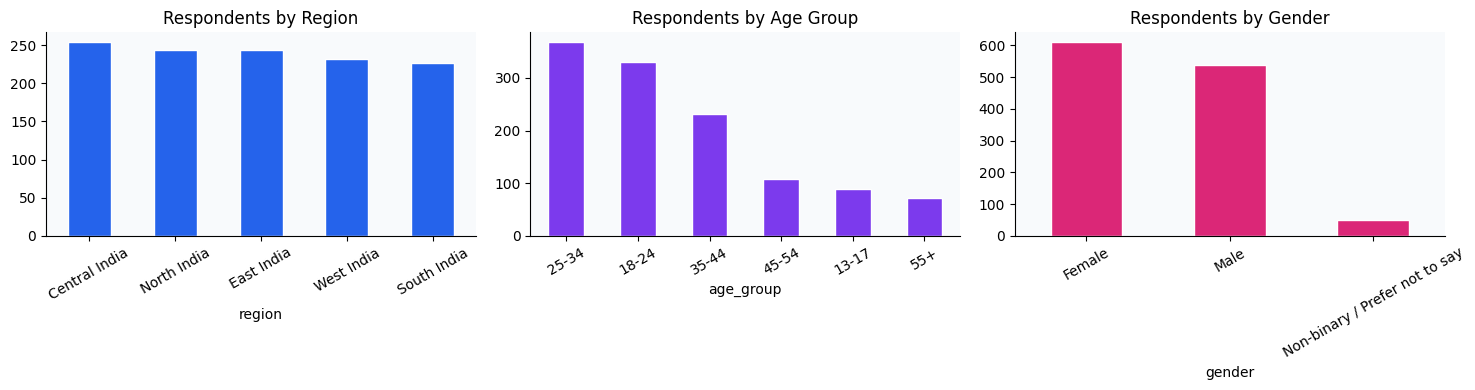

In [ ]:
print('=== BASIC STATS ===')
print(f'Total respondents: {len(df):,}')
print(f'Regions: {df.region.nunique()} → {df.region.unique()}')
print(f'Age Groups: {df.age_group.nunique()} → {df.age_group.unique()}')
print(f'Survey period: {df.response_date.min().date()} → {df.response_date.max().date()}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['region'].value_counts().plot(kind='bar', ax=axes[0], color='#2563EB', edgecolor='white')
axes[0].set_title('Respondents by Region')
axes[0].tick_params(axis='x', rotation=30)

df['age_group'].value_counts().plot(kind='bar', ax=axes[1], color='#7C3AED', edgecolor='white')
axes[1].set_title('Respondents by Age Group')
axes[1].tick_params(axis='x', rotation=30)

df['gender'].value_counts().plot(kind='bar', ax=axes[2], color='#DB2777', edgecolor='white')
axes[2].set_title('Respondents by Gender')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/charts/00_eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Vote Share Analysis

In [ ]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from analysis import overall_vote_share

df = pd.read_csv("../data/poll_data_clean.csv")

vote = overall_vote_share(df)
print("Platform Vote Share:")
display(vote)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2563EB', '#7C3AED', '#DB2777', '#D97706', '#059669', '#DC2626']

ax1.barh(vote['Option'], vote['Percentage'], color=colors[:len(vote)], edgecolor='white')
for i, (pct, cnt) in enumerate(zip(vote['Percentage'], vote['Count'])):
    ax1.text(pct + 0.2, i, f'{pct:.1f}% ({cnt:,})', va='center', fontsize=9)

ax1.set_title('Vote Share - Bar Chart', fontweight='bold')
ax1.invert_yaxis()

wedges, _, autos = ax2.pie(
    vote['Percentage'],
    labels=None,
    colors=colors[:len(vote)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)

for at in autos:
    at.set_fontsize(9)
    at.set_color('white')

ax2.text(0, 0, f'{vote['Count'].sum():,}\nVotes', ha='center', va='center', fontsize=12, fontweight='bold')
ax2.legend(vote['Option'], loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.1), frameon=False)
ax2.set_title('Vote Share - Donut Chart', fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/01_vote_share_notebook.png", dpi=150, bbox_inches='tight')
plt.show()


NameError: name 'df' is not defined

## 6. Regional Analysis

In [ ]:
from analysis import region_wise_breakdown

region_df = region_wise_breakdown(df)
print('Region-wise Breakdown (%):')
display(region_df)

fig, ax = plt.subplots(figsize=(12, 5))
region_df.plot(kind='bar', stacked=True, ax=ax,
    color=['#2563EB','#7C3AED','#DB2777','#D97706','#059669','#DC2626'],
    edgecolor='white', linewidth=0.5)
ax.set_title('Platform Preference by Region (Stacked %)', fontweight='bold', fontsize=13)
ax.set_ylabel('Share (%)')
ax.set_ylim(0, 108)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/charts/03_region_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Demographic Heatmap

In [ ]:
from analysis import age_group_breakdown

age_df = age_group_breakdown(df)
display(age_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(age_df, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, linecolor='#E2E8F0', ax=ax,
    cbar_kws={'label': '% of Age Group'})
ax.set_title('Platform Preference by Age Group (%)', fontweight='bold', fontsize=13)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../outputs/charts/04_age_heatmap_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Satisfaction Analysis

In [ ]:
from analysis import satisfaction_by_platform, net_satisfaction_score

sat = satisfaction_by_platform(df)
nss = net_satisfaction_score(df)

print('Satisfaction by Platform:')
display(sat)
print(f'\nNet Satisfaction Score: {nss["net_satisfaction_score"]:+.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2563EB','#7C3AED','#DB2777','#D97706','#059669','#DC2626']
bars = ax.bar(sat['Platform'], sat['Avg_Satisfaction_Score'],
    color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, sat['Avg_Satisfaction_Score']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
        f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=sat['Avg_Satisfaction_Score'].mean(), color='gray',
    linestyle='--', label=f'Mean: {sat["Avg_Satisfaction_Score"].mean():.2f}')
ax.set_ylim(0, 5.5)
ax.set_ylabel('Avg. Satisfaction Score (1–5)')
ax.set_title('Q4 — Average Satisfaction Score per Platform', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/charts/06_satisfaction_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Monthly Trend

In [ ]:
from analysis import monthly_trend

trend = monthly_trend(df, top_n=3)
display(trend)

fig, ax = plt.subplots(figsize=(12, 5))
markers = ['o','s','D']
colors = ['#2563EB','#7C3AED','#DB2777']
for i, col in enumerate(trend.columns):
    ax.plot(trend.index, trend[col], marker=markers[i], linewidth=2.5,
        color=colors[i], label=col, markersize=8)
ax.set_xlabel('Month')
ax.set_ylabel('Response Count')
ax.set_title('Monthly Response Trend — Top 3 Platforms', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/charts/05_trend_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Executive Summary & Insights

In [ ]:
from analysis import generate_summary
print(generate_summary(df))

## ✅ Notebook Complete

**Key Takeaways:**
1. Instagram leads overall platform preference across demographics.
2. Younger age groups (13–24) show the strongest preference for Instagram.
3. Older users (45+) prefer Facebook significantly more than younger users.
4. Net Satisfaction Score indicates majority positive sentiment.
5. South India shows the highest YouTube preference.

**Next Steps:**
- Add real Google Form export data
- Extend with NLP for open-ended responses
- Deploy Streamlit dashboard to Streamlit Cloud